# Running Cali

In the following notebook, we're going to install and run the Cali calibration pole detection and annotation model.

Let's start by installing the package.

In [15]:
# Install Cali
!pip install -q git+https://github.com/bencevans/cali.git

# Install a a few aux libs to pretty print outputs and display images.
!pip install -q rich Pillow

# Import aux libs
from PIL import Image
from rich import print

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Now that's installed, we can import the model and a plotting helper.

Instatiating the Cali class will automatically download the model and set it up with a default device, this will be your graphics card if you have a compatible device, the mps accellorator if you're running this notebook locally on an Apple Silicon device.

In [13]:
from cali import Cali, plot_result


model = Cali()

Found https://static.bencevans.io/cali/models/v0-yolo26n-pose-best.pt locally at weights/v0-yolo26n-pose-best.pt


We've now got the model loaded. We'll create a helper function to download some example imagery. Alternatively, add your own imagery using the Colab file explorer.

In [18]:
from requests import get
from pathlib import Path

data_path = Path("./data")
data_path.mkdir(exist_ok=True)

def download_file(url, output):
  response = get(url)
  with open(output, "wb") as fh:
    fh.write(response.content)


download_file("https://raw.githubusercontent.com/bencevans/cali/refs/heads/main/images/0001.JPG", data_path / "0001.JPG")
!ls data

0001.JPG


Now we have some files, let's run detection on a single file.

In [20]:


result = model.detect("data/0001.JPG")
print(result)


0: 384x640 1 calibration_pole, 216.1ms
Speed: 6.3ms preprocess, 216.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


ImageResult(
    image_path='data/0001.JPG',
    width=2688,
    height=1512,
    detections=[
        Detection(
            confidence=0.8780001997947693,
            name='calibration_pole',
            bounding_box=(2144.53173828125, 0.0, 2304.818603515625, 1431.27294921875),
            keypoints=[
                HeightKeypoint(
                    name='height',
                    x=2246.26904296875,
                    y=916.3339233398438,
                    height=0.4,
                    confidence=0.8899941444396973
                ),
                HeightKeypoint(
                    name='height',
                    x=2214.254150390625,
                    y=506.87103271484375,
                    height=0.6,
                    confidence=0.9777626395225525
                ),
                HeightKeypoint(
                    name='height',
                    x=2210.25439453125,
                    y=97.87860107421875,
                    height=0.8,
                    confidence=0.8214975595474243
                )
            ]
        )
    ]
)

The model has one calibration pole detection with 3 height marker keypoints. This is the standard output format from the Cali model. When run Cali from command line, the output will be in the same format.

There's a plotting helper included in the cali package. Let's take a look.

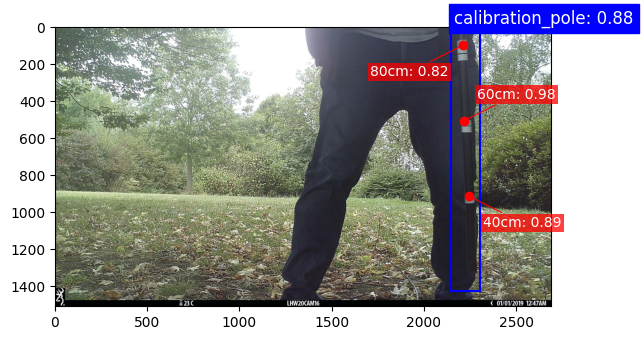

In [21]:
plot_result(result)

To run on a large batch of images we can either program it or use the command line interface. We can check the command line interface has been installed by checking the help message prints when we run the following.

In [23]:
!cali --help

usage: cali [-h] {detect,plot} ...

Calibration Pole Detector and Annotator

positional arguments:
  {detect,plot}
    detect       Detect calibration poles in an image
    plot         Plot detected calibration poles in an image

options:
  -h, --help     show this help message and exit


There are two subcommands for the CLI, detect and plot. Let's focus on detect to processes multiple images.

In [24]:
!cali detect --help

usage: cali detect [-h] [--conf-threshold CONF_THRESHOLD] [--recursive]
                   [--relative]
                   image_source output

positional arguments:
  image_source          Path to the input image
  output                Path to save the full JSON results

options:
  -h, --help            show this help message and exit
  --conf-threshold CONF_THRESHOLD
                        Confidence threshold for detections
  --recursive           Recurse into subdirectories
  --relative            Store image paths relative to image_source in the JSON
                        output


There's a few different options we can specify but the vital onces are image_source which is the path to our images and output which is the path to where we want our results JSON file to be saved.

Optionally we may want to specify --recursive to find all images in subfolders of the image_source and --relative which will save the file_paths in the output JSON relative to the image_source.

In [25]:
!cali detect --recursive --relative data/ detections.json

Found https://static.bencevans.io/cali/models/v0-yolo26n-pose-best.pt locally at weights/v0-yolo26n-pose-best.pt

0: 384x640 1 calibration_pole, 146.2ms
Speed: 4.5ms preprocess, 146.2ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
0001.JPG: 1 detection(s), 3 keypoint(s)
Results saved to detections.json


Once it's finished running we'll have all the results saved in the JSON file.

In [26]:
from json import load

print(load(open("detections.json"))[:5])
# limited to printing the first 5 in case you've added a lot!


[
    {
        'image_path': '0001.JPG',
        'width': 2688,
        'height': 1512,
        'detections': [
            {
                'confidence': 0.8780001997947693,
                'name': 'calibration_pole',
                'bounding_box': [2144.53173828125, 0.0, 2304.818603515625, 1431.27294921875],
                'keypoints': [
                    {
                        'name': 'height',
                        'x': 2246.26904296875,
                        'y': 916.3339233398438,
                        'height': 0.4,
                        'confidence': 0.8899941444396973
                    },
                    {
                        'name': 'height',
                        'x': 2214.254150390625,
                        'y': 506.87103271484375,
                        'height': 0.6,
                        'confidence': 0.9777626395225525
                    },
                    {
                        'name': 'height',
                        'x': 2210.25439453125,
                        'y': 97.87860107421875,
                        'height': 0.8,
                        'confidence': 0.8214975595474243
                    }
                ]
            }
        ]
    }
]